In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras import regularizers
import tensorflow as tf
from keras.callbacks import EarlyStopping

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
print('Number of categories:',len(set(y_train)))

Number of categories: 10


In [6]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")


X_train /= 255
X_test /= 255


Y_train =  to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

In [7]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train)

In [8]:
print('Size of the train set:', X_train.shape)

Size of the train set: (45000, 784)


In [9]:
pesi = "problem_one.weights.h5"

In [10]:
se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()

input_dim = X_train.shape[1]

model = Sequential()
model.add(Dense(512, activation='relu', input_dim=input_dim,
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(128, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(64, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(10, activation='softmax',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))

optimizer = keras.optimizers.Adam(learning_rate=0.1)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.load_weights(pesi)

model.summary()

C:\Users\emmaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\emmaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,490 (1.82 MB)

 Trainable params: 476,490 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
start = time.time()
history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=10,
    batch_size=128
)
end = time.time()
print("Training time:", end-start)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1937 - loss: 1.7625 - val_accuracy: 0.1954 - val_loss: 1.7601
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1960 - loss: 1.8038 - val_accuracy: 0.1756 - val_loss: 1.9975
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1960 - loss: 1.8146 - val_accuracy: 0.1995 - val_loss: 1.7508
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1950 - loss: 1.7562 - val_accuracy: 0.1987 - val_loss: 1.7407
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1960 - loss: 1.7519 - val_accuracy: 0.1987 - val_loss: 1.7411
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1961 - loss: 1.7519 - val_accuracy: 0.1987 - val_loss: 1.7415
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1964 - loss: 1.7519 - val_accuracy: 0.1987 - val_loss: 1.7419
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1963 - loss: 1.7519 - val_accuracy: 0.

In [12]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1987 - loss: 1.7425  
Test Loss: 1.7425
Test Accuracy: 0.1987


In [13]:
for layer in model.layers:
  print(layer.get_config(),
        layer.get_weights(),)

{'name': 'dense', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 512, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'RandomNormal', 'config': {'seed': 42, 'mean': 0.0, 'stddev': 0.05}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None} [array([[-2.8827000e-02,  2.9974386e-02,  2.0687595e-02, ...,
         4.4879481e-02,  6.3579679e-02,  4.1498698e-02],
       [-3.5581738e-04, -5.4865185e-02,  2.3366369e-02, ...,
         4.5538858e-02, -2.5132705e-02, -2.3300037e-02],
       [-4.5976579e-02, -5.2006215e-01, -5.4054058e-01, ...,
        -5.4729557e-01, -5.0024861e-01, -5.3475893e-01],
       ...,
       [ 5.4809165e-01, -6.2820077e-01, -

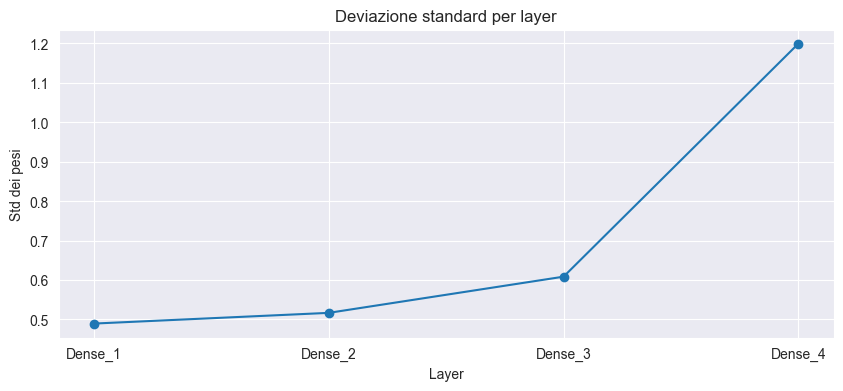

In [14]:
layer_names = []
std_weights = []
layercount = 0

for layer in model.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        w = weights[0].flatten()
        layercount += 1
        layer_names.append(f"Dense_{layercount}")
        std_weights.append(np.std(w))

plt.figure(figsize=(10, 4))
plt.plot(layer_names, std_weights, marker='o')
plt.title("Deviazione standard per layer")
plt.xlabel("Layer")
plt.ylabel("Std dei pesi")
plt.grid(True)
plt.savefig("grafici/ds-layer.png")
plt.show()

#Modello con problemi risolti

In [15]:
se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()

input_dim = X_train.shape[1]

model2 = Sequential()
model2.add(Dense(512, activation='relu', input_dim=input_dim,
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model2.add(Dense(128, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model2.add(Dense(64, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model2.add(Dense(10, activation='softmax',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model2.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,490 (1.82 MB)

 Trainable params: 476,490 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
start = time.time()
history2 = model2.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=20,
    batch_size=128
)
end = time.time()
print("Training time:", end-start)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7821 - loss: 0.6127 - val_accuracy: 0.8432 - val_loss: 0.4404
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8570 - loss: 0.4008 - val_accuracy: 0.8590 - val_loss: 0.3945
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8714 - loss: 0.3521 - val_accuracy: 0.8645 - val_loss: 0.3808
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8829 - loss: 0.3195 - val_accuracy: 0.8617 - val_loss: 0.3813
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8901 - loss: 0.2971 - val_accuracy: 0.8619 - val_loss: 0.3821
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8964 - loss: 0.2795 - val_accuracy: 0.8624 - val_loss: 0.3818
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9028 - loss: 0.2629 - val_accuracy: 0.8714 - val_loss: 0.3697
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9074 - loss: 0.2497 - val_accuracy: 0.

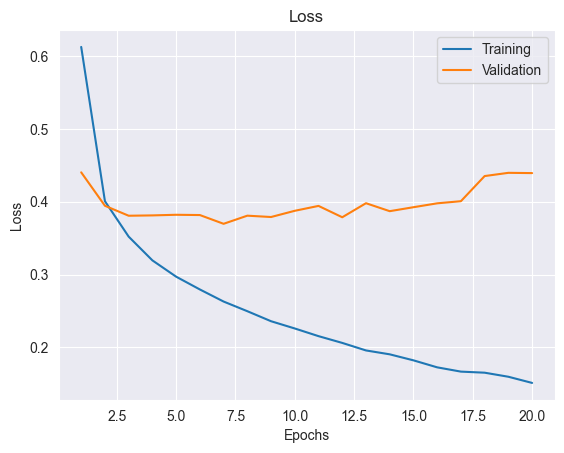

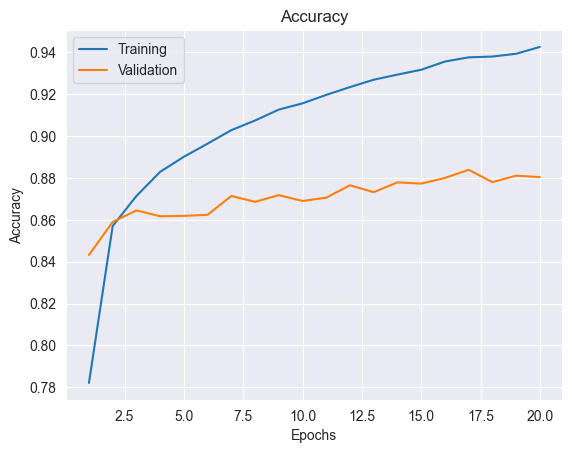

In [17]:
def plot_loss(history):
  x_plot = list(range(1,len(history.history["loss"])+1))
  plt.figure()
  plt.title("Loss")
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.plot(x_plot, history.history['loss'])
  plt.plot(x_plot, history.history['val_loss'])
  plt.legend(['Training', 'Validation'])

def plot_accuracy(history):
  x_plot = list(range(1,len(history.history["accuracy"])+1))
  plt.figure()
  plt.title("Accuracy")
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.plot(x_plot, history.history['accuracy'])
  plt.plot(x_plot, history.history['val_accuracy'])
  plt.legend(['Training', 'Validation'])

plot_loss(history2)
plt.savefig("grafici/loss2.png")
plot_accuracy(history2)
plt.savefig("grafici/accuracy2.png")

In [18]:
loss2, accuracy2 = model2.evaluate(X_test, Y_test)
print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8804 - loss: 0.4394  
Test Loss: 0.4394
Test Accuracy: 0.8804


In [19]:
for layer in model2.layers:
  print(layer.get_config(),
        layer.get_weights(),)

{'name': 'dense_4', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 512, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'RandomNormal', 'config': {'seed': 42, 'mean': 0.0, 'stddev': 0.05}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None} [array([[-0.40681386, -0.36624295,  0.00970839, ...,  0.181446  ,
        -0.10306232, -0.37189278],
       [-0.04714901, -0.2353817 , -0.17885356, ...,  0.08469123,
         0.1089623 ,  0.48574907],
       [-0.05308236, -0.29753047, -0.1369162 , ...,  0.20784082,
        -0.18021029,  0.3075515 ],
       ...,
       [ 0.13953453,  0.11905608, -0.04166135, ...,  0.05534608,
        -0.06636641,  0.2321

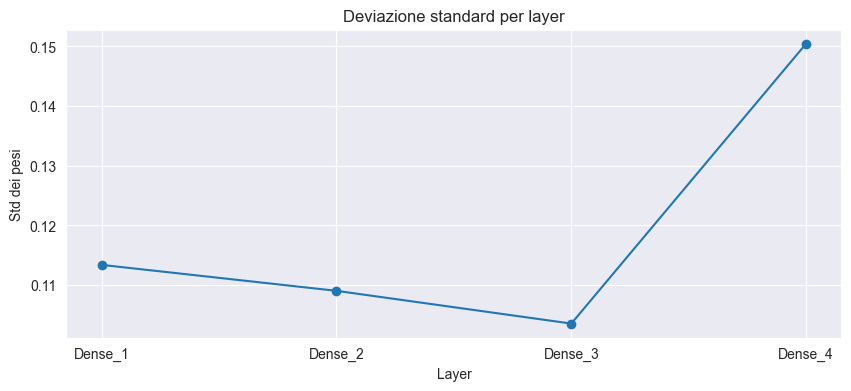

In [20]:
layer_names = []
std_weights = []
layercount = 0

for layer in model2.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        w = weights[0].flatten()
        layercount += 1
        layer_names.append(f"Dense_{layercount}")
        std_weights.append(np.std(w))

plt.figure(figsize=(10, 4))
plt.plot(layer_names, std_weights, marker='o')
plt.title("Deviazione standard per layer")
plt.xlabel("Layer")
plt.ylabel("Std dei pesi")
plt.grid(True)
plt.savefig("grafici/ds-layer2.png")
plt.show()

#Modello senza overfitting

In [21]:
se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()

input_dim = X_train.shape[1]
reg = 0.001

model3 = Sequential()
model3.add(Dense(512, activation='relu', input_dim=input_dim,
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model3.add(Dropout(0.4, seed=se))
model3.add(Dense(128, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model3.add(Dropout(0.4, seed=se))
model3.add(Dense(64, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model3.add(Dropout(0.4, seed=se))
model3.add(Dense(10, activation='softmax',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model3.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,490 (1.82 MB)

 Trainable params: 476,490 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()
history3 = model3.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop]
)
end = time.time()

print("Training time:", end-start)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6282 - loss: 1.6259 - val_accuracy: 0.7835 - val_loss: 0.9603
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7859 - loss: 0.9244 - val_accuracy: 0.8218 - val_loss: 0.7558
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8124 - loss: 0.7767 - val_accuracy: 0.8344 - val_loss: 0.6649
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8247 - loss: 0.7057 - val_accuracy: 0.8395 - val_loss: 0.6305
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8327 - loss: 0.6618 - val_accuracy: 0.8418 - val_loss: 0.6071
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8385 - loss: 0.6280 - val_accuracy: 0.8506 - val_loss: 0.5734
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8410 - loss: 0.6169 - val_accuracy: 0.8550 - val_loss: 0.5591
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8457 - loss: 0.5970 - val_accuracy: 0.

In [23]:
loss3, accuracy3 = model3.evaluate(X_test, Y_test)
print(f"Test Loss: {loss3:.4f}")
print(f"Test Accuracy: {accuracy3:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8649 - loss: 0.5161
Test Loss: 0.5161
Test Accuracy: 0.8649


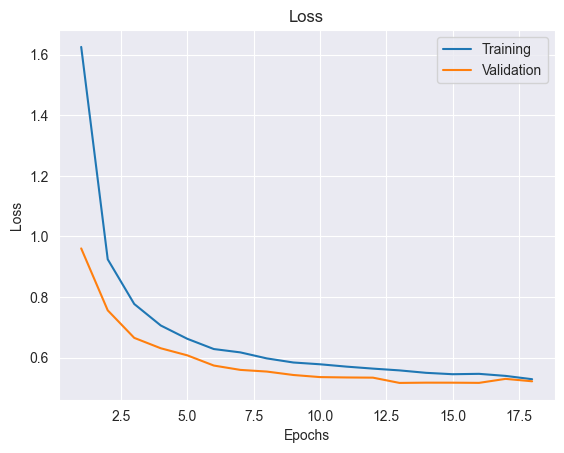

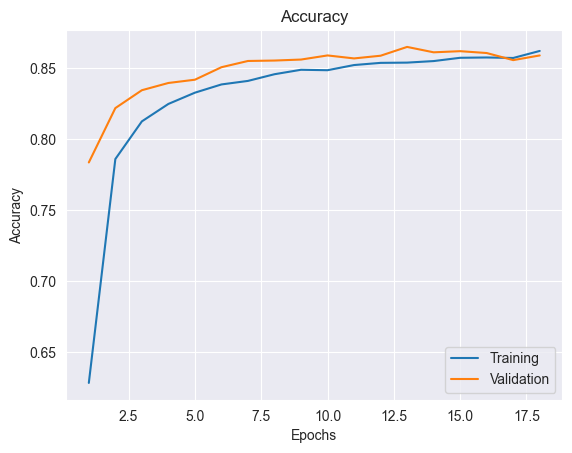

In [24]:
plot_loss(history3)
plt.savefig("grafici/loss3.png")
plot_accuracy(history3)
plt.savefig("grafici/accuracy3.png")

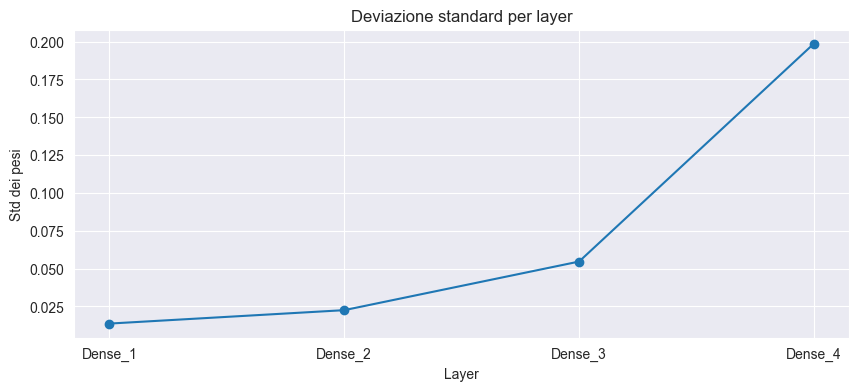

In [25]:
layer_names = []
std_weights = []
layercount = 0

for layer in model3.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        w = weights[0].flatten()
        layercount += 1
        layer_names.append(f"Dense_{layercount}")
        std_weights.append(np.std(w))

plt.figure(figsize=(10, 4))
plt.plot(layer_names, std_weights, marker='o')
plt.title("Deviazione standard per layer")
plt.xlabel("Layer")
plt.ylabel("Std dei pesi")
plt.grid(True)
plt.savefig("grafici/ds-layer3.png")
plt.show()